##Developing Cohesive Group Emotion Recognition using OpenCV and Deepface

This project group emotion recognition by integrating OpenCV's powerful face detection capabilities, DeepFace's pre-trained models for nuanced emotion recognition, and a dependency injection approach for enhanced extensibility. Leveraging OpenCV's Haar Cascade for face detection, the project applies DeepFace's deep learning models to recognize individual emotions within groups, emphasizing adaptability and scalability without custom model training.

The project's innovation extends to its evaluation, incorporating analysis on low-light images, crowded scenarios with over 10 individuals, and scenarios with obscured or unclear facial features.the cross-entropy analysis refines the model's accuracy in recognizing diverse emotions within group images.

Additionally, the project implements confusion matrix methodologies to analyze the model's performance, showcasing its ability to differentiate individual emotions within group settings.

##Colab Notebook Setup Instructions
To set up the Colab notebook, import or drag and drop the 'setup.zip' file into the Colab content section (/content/). Then, navigate to the 'Runtime' section in the menu bar and select the 'Run all' menu item to execute the setup process

In [137]:
import os.path
from os import path
#this will extract the test file in content section
if path.exists('/content/Setup') == False:
  !unzip '/content/Setup.zip'

Install rquired packages

In [138]:
#install pakages
!pip install opencv-python
!pip install deepface

In [139]:
from deepface import DeepFace
import cv2
import multiprocessing
import os
import numpy as np

Config class

In [140]:
class Config:
    # File paths
    LABEL_FILE = '/content/Setup/TestImagesSet/Labels.json'
    IMAGE_DIRECTORY = '/content/Setup/TestImagesSet/'
    FACE_CASCADE_PATH = '/content/Setup/HaarcascadeFile/haarcascade_frontalface_default.xml'

    # Emotions label categories
    EMOTIONS_LABEL = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

    # Face detection parameters
    FACE_SCALE_FACTOR = 1.1  # Parameter for face detection
    FACE_MIN_NEIGHBORS = 5  # Minimum neighbors parameter for face detection


Emotion recognition using DeepFace

In [141]:
# Importing the DeepFace library
from deepface import DeepFace

class DeepFaceWrapper:
   #In
    def __init__(self):
       # Initializing the emotion recognition model
        self.emotion_model = DeepFace.build_model('Emotion')

    # Predict the dominant emotion from the face image
    def predict_dominant_emotion(self, face):
        emotion_prediction = DeepFace.analyze(face, actions=['emotion'], enforce_detection = False)
        return emotion_prediction[0]['dominant_emotion'] # Returning the dominant emotion prediction

    # Perform emotion recognition on the face; if the image is not a face, it raises an exception
    def predict_emotion(self, face):
      try:
        emotion_prediction = DeepFace.analyze(face, actions=['emotion'], enforce_detection = True)
        # Returning the predicted emotion
        return emotion_prediction[0]['emotion']
      except:
        # Handling exception when face detection fails; currently set to return 0 as a placeholder
        pass  # To be updated to handle exceptions or return appropriate values

OpenCV for finding faces.

In [142]:
# Importing OpenCV
import cv2
class OpencvWrapper:
  def __init__(self):
    # Initializing face detection classifier
    self.face_cascade = cv2.CascadeClassifier(Config.FACE_CASCADE_PATH)

  # Detect faces in the provided image using the initialized face detection classifier
  def detect_faces(self, image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Convert image to grayscale
    # Detect faces in the grayscale image using detectMultiScale
    faces = self.face_cascade.detectMultiScale(gray_image, scaleFactor=Config.FACE_SCALE_FACTOR, minNeighbors=Config.FACE_MIN_NEIGHBORS)
    return faces # Return the detected faces

  # Load an image from the specified path using OpenCV
  def load_image(self, image_path):
    return cv2.imread(image_path)

In [143]:
import matplotlib.pyplot as plt
def draw_face(img_rgb, emotion_str):
  plt.figure(figsize=(2,2))
  plt.imshow(img_rgb)
  plt.title(emotion_str)
  plt.axis('off')

Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 17.68it/s]


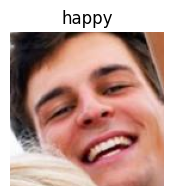

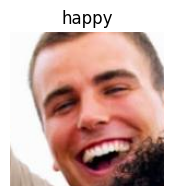

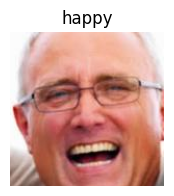

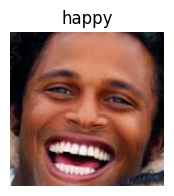

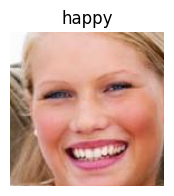

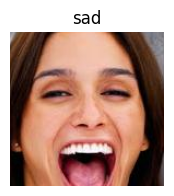

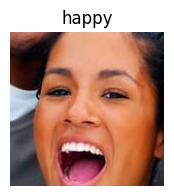

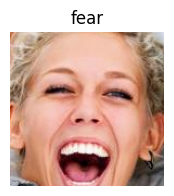

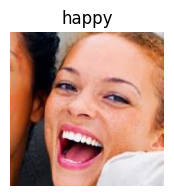

In [144]:
#Face Detection Test: Detecting Faces in Group Images
def draw_faces(image_path):
  ow = OpencvWrapper()
  ew = DeepFaceWrapper()
  img = ow.load_image(image_path)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  faces = ow.detect_faces(ow.load_image(image_path))

  for (x, y, w, h) in faces:
    #cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 0, 255), 2)
    face = img_rgb[y:y+h, x:x+w]
    #print(ew.predict_dominant_emotion(face))
    draw_face(face, ew.predict_dominant_emotion(face))

image_path = '/content/Setup/TestImagesSet/Test/12_Group_Group_12_Group_Group_12_183.jpg'
draw_faces(image_path)

The EmotionRecognition class analyzes emotions within a group image using face and emotion wrapper objects. It employs methods to process images, detect faces, and predict emotions for each detected face. The predicted emotions are preprocessed for further analysis, enabling the exploration of emotions within collective settings.

In [145]:
class EmotionRecognition:
  def __init__(self, face_wrapper, emotion_wrapper):
    self.face_wrapper = face_wrapper # Initializing face wrapper object
    self.emotion_wrapper = emotion_wrapper # Initializing emotion wrapper object

  def analyze_group_emotions(self, image_path):
    individual_emotions = [] # List to store individual emotions

    def process_image(image_path):
      group_image = self.face_wrapper.load_image(image_path)  # Load image using face wrapper
      faces = self.face_wrapper.detect_faces(group_image) # Detect faces in the image
       # Predict emotions for each detected face
      emotions = [self.emotion_wrapper.predict_emotion(group_image[y:y+h, x:x+w]) for (x, y, w, h) in faces]
      return emotions

    def preprocess_emotions(emotions):
      emotionsMatrix = []
      for emotion in emotions:
        emotionsMatrix.append([emotion[label] for label in emotion])
      return emotionsMatrix

    # Process the image to detect faces and analyze emotions
    prob_emotions = process_image(image_path)
    emotions = [label for label in prob_emotions if label is not None]
    # Return preprocessed emotions for analysis
    return preprocess_emotions(emotions)

In [146]:
import matplotlib.pyplot as plt
def draw_photo(image_path, emotion):
  img = cv2.imread(imagePath)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(3,3))
  plt.imshow(img_rgb)
  plt.title(emotion)
  plt.axis('off')

Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 14.02it/s]


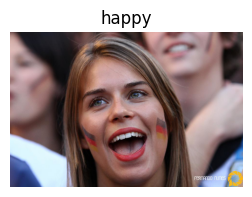

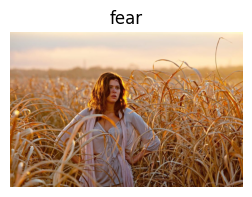

In [147]:
#Quickly testing the model in happy path scenarios to verify expected functionality.
#['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

fw = OpencvWrapper()
ew = DeepFaceWrapper()
er = EmotionRecognition(fw, ew)

# Define image paths
image_paths = [
    '/content/Setup/TestImagesSet/Test/1955.jpg',
    '/content/Setup/TestImagesSet/Test/11_Meeting_Meeting_11_Meeting_Meeting_11_735.jpg',
    #'/content/Setup/TestImagesSet/Test/12_Group_Group_12_Group_Group_12_93.jpg'
]

# Process images and display emotions
for imagePath in image_paths:
    face_emotions = er.analyze_group_emotions(imagePath)
    draw_photo(imagePath, Config.EMOTIONS_LABEL[np.argmax(face_emotions)])

# Calculate Cross Entropy for group images

In [148]:
 #This function converts the emotion library output to a normalized matrix for cross-entropy calculation
def getting_predicted_emotions(emotions):
  predicted_emotions = [] # List to store normalized emotions

  # Loop through each emotion prediction
  for emotion in emotions[0]:
     # Extract each emotion's values and create a normalized list
    predicted_emotions.append([emotion[label] for label in emotion])
  # Return the normalized emotion matrix
  return predicted_emotions

In [149]:
import json
import numpy as np

def getting_true_emotions(image_name, actual_emotions, image_label):
    # Load emotion labels from a JSON file
    with open(image_label, 'r') as json_file:
        label_data = json.load(json_file)

    # Extract emotion labels for the specified image
    label_faces = next((item for item in label_data if item.get(image_name)), {}).get(image_name, [])

    # Create an empty label matrix to represent emotions for detected faces
    num_faces = len(label_faces)
    num_emotions = len(actual_emotions)
    label_matrix = np.zeros((num_faces, num_emotions), dtype=int)

    # Populate the label matrix based on detected faces and their associated emotions
    for face_index, face_label in enumerate(label_faces):
        if face_label in actual_emotions:
            emotion_index = actual_emotions.index(face_label)
            label_matrix[face_index, emotion_index] = 1  # Set the corresponding emotion label to 1

    # Return the label matrix representing emotions for detected faces
    return label_matrix

The function computes the cross-entropy loss between predicted emotion probabilities and true emotions. It first ensures the predicted emotion matrix matches the length of true emotions, padding if necessary. Converting data to PyTorch tensors, it adjusts tensor shapes and computes the cross-entropy loss using F.cross_entropy. The function ensures correct data types and shapes for the computation of the loss.

In [150]:
import torch
import torch.nn.functional as F
import numpy as np

def calculate_cross_entropy_loss(predicted_emotion, true_emotions):
    # Ensure predicted_emotion matrix has the same length as true_emotions
    diff = len(true_emotions) - len(predicted_emotion)
    if diff > 0:
        # Pad predicted_emotion with zero-filled rows to match the length of true_emotions
        zero_padding = [list(np.zeros(len(true_emotions[0])))] * diff
        predicted_emotion.extend(zero_padding)

    # Convert data to PyTorch tensors
    true_emotions = torch.LongTensor(true_emotions)  # Ensure true_emotions is of type Long
    predicted_emotion = torch.Tensor(predicted_emotion)

    # Get the class indices from true_emotions
    true_class_indices = torch.argmax(true_emotions, dim=1)

    # Calculate cross-entropy loss using class indices
    loss = F.cross_entropy(predicted_emotion, true_class_indices)
    return loss

## Confusion Matrix Calculation and Visualization


In [151]:
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Calculates the confusion matrix.
def plot_confusion_matrix(true_labels, predicted_labels):
    true_labels = np.argmax(true_labels, axis=1)
    predicted_labels = np.argmax(predicted_labels, axis=1)
    confusion_mat = confusion_matrix(true_labels, predicted_labels)

    unique_emotions = set(list(true_labels) + list(predicted_labels))
    unique_labels = [Config.EMOTIONS_LABEL[index] for index in unique_emotions]

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

Utility Function

In [152]:
def get_file_name(file_path):
    # Split the file path by '/'
    file_path_components = file_path.split('/')

    # Get the file name with extension from the last component of the path
    file_name_with_extension = file_path_components[-1]

    # Split the file name and extension using the last dot as the separator
    file_name, _ = file_name_with_extension.rsplit('.', 1)

    # Return the file name without the extension
    return file_name



The validate function performs emotion recognition validation within a group of images. It initializes necessary configurations and dependencies using OpenCV and DeepFace. By analyzing individual emotions in each image, it accumulates predicted and actual emotions, calculates cross-entropy losses, and determines the group-level average loss. Finally, it generates a confusion matrix to visualize the model's performance in differentiating emotions within the group, facilitating evaluation and refinement of the emotion recognition system.

In [153]:
def validate(image_directory, image_label):
    config = Config()

    # Inject dependencies
    face_wrapper = OpencvWrapper()
    emotion_wrapper = DeepFaceWrapper()
    emotion_recognition = EmotionRecognition(face_wrapper, emotion_wrapper)

    # Read image paths from the provided directory
    image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename != '.ipynb_checkpoints']

    predicted_emotions = []
    true_emotions = []
    individual_face_losses = []

    for image_path in image_paths:
        image_name = get_file_name(image_path)
        print(f"Image name: {image_name}")

        # Analyze emotions for each individual picture from the group of images
        face_emotions = emotion_recognition.analyze_group_emotions(image_path)
        predicted_emotions.extend(face_emotions)
        draw_faces(image_path)

        actual_face_emotions = getting_true_emotions(image_name, config.EMOTIONS_LABEL, image_label)
        true_emotions.extend(actual_face_emotions)

        loss = calculate_cross_entropy_loss(face_emotions, actual_face_emotions)
        individual_face_losses.append(loss.item())

    total_loss = calculate_cross_entropy_loss(predicted_emotions, true_emotions)
    print(f"Cross-Entropy Total Loss: {total_loss.item():.4f}")

    # Calculate the mean of individual face losses to obtain the group-level average loss
    group_loss = np.mean(individual_face_losses)
    print(f"Cross-Entropy Group-level Average Loss: {group_loss:.4f}")

    # Report individual image losses
    for i, loss in enumerate(individual_face_losses):
        print(f"Image {i + 1} Loss: {loss:.4f}")

    # Calculate and plot confusion matrix
    plot_confusion_matrix(true_emotions, predicted_emotions)


## Validations/Evaluation and observations

Scenario with clear images and a limited number of persons

Image name: 20_Family_Group_Family_Group_20_926


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 12.32it/s]


Image name: 17_Ceremony_Ceremony_17_781


Action: emotion: 100%|██████████| 1/1 [00:00<00:00,  4.25it/s]


Image name: 29_Students_Schoolkids_Students_Schoolkids_29_911


...

Image name: 12_Group_Team_Organized_Group_12_Group_Team_Organized_Group_12_784


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 12.21it/s]


Image name: 56_Voter_peoplevoting_56_406


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 13.85it/s]


Image name: 56_Voter_peoplevoting_56_745
Image name: 56_Voter_peoplevoting_56_381
Cross-Entropy Total Loss: 29.9609
Cross-Entropy Group-level Average Loss: 22.1358
Image 1 Loss: 0.0000
Image 2 Loss: 1.9459
Image 3 Loss: 98.9491
Image 4 Loss: 53.7423
Image 5 Loss: 39.7197
Image 6 Loss: 0.9730
Image 7 Loss: 0.0000
Image 8 Loss: 1.9459
Image 9 Loss: 1.9459


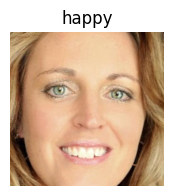

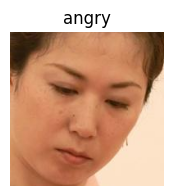

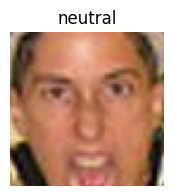

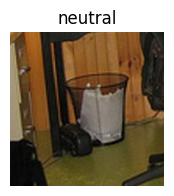

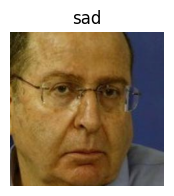

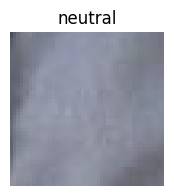

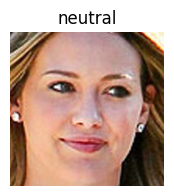

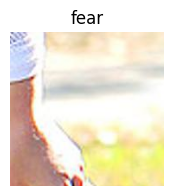

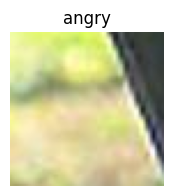

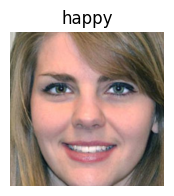

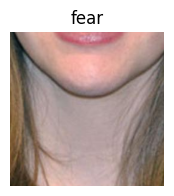

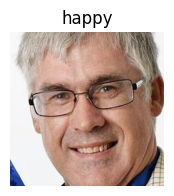

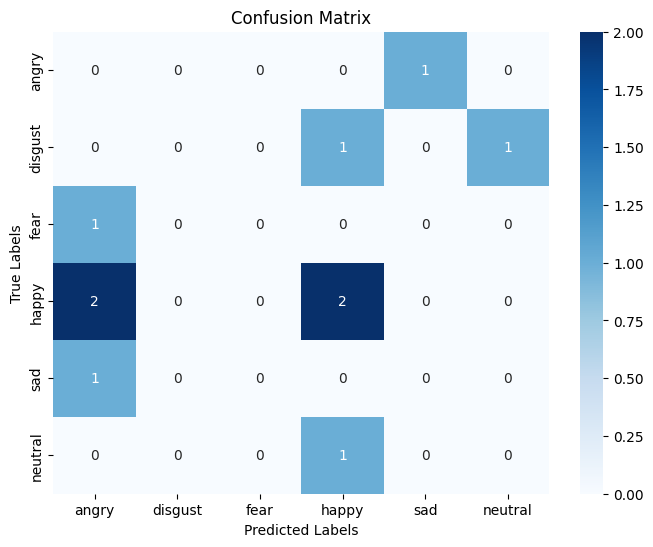

In [154]:
# Validate Scenario with clear images and a limited number of persons
# First parameter is the test file location
# Second parameter is the label file location
validate(Config.IMAGE_DIRECTORY + 'ClearImages', Config.LABEL_FILE)

#Final observation:
#The model's performance, as indicated by the Cross-Entropy Total Loss of 20.2718 and the Cross-Entropy Group-level Average Loss of 10.4819,
#significant discrepancies between predicted and actual emotions within the group images. These values imply a substantial divergence from the expected emotions

Number of Persons in Image Above 10

Image name: 20_Family_Group_Family_Group_20_716


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 21.19it/s]


Image name: 12_Group_Group_12_Group_Group_12_882


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 19.43it/s]


Image name: 20_Family_Group_Family_Group_20_420


...

Image name: 12_Group_Large_Group_12_Group_Large_Group_12_20


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 19.74it/s]


Image name: 12_Group_Team_Organized_Group_12_Group_Team_Organized_Group_12_351


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 20.77it/s]


Cross-Entropy Total Loss: 13.5327
Cross-Entropy Group-level Average Loss: 10.3138
Image 1 Loss: 10.0342
Image 2 Loss: 19.9652
Image 3 Loss: 12.4402
Image 4 Loss: 5.1298
Image 5 Loss: 12.4835
Image 6 Loss: 20.7459
Image 7 Loss: 0.8340
Image 8 Loss: 1.9459
Image 9 Loss: 10.7353
Image 10 Loss: 11.3609
Image 11 Loss: 7.7772


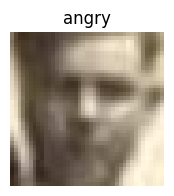

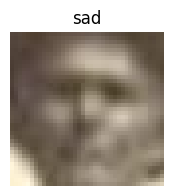

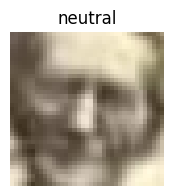

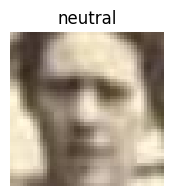

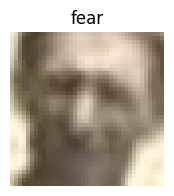

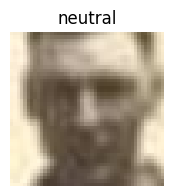

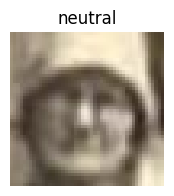

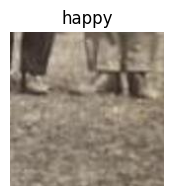

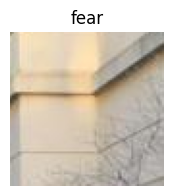

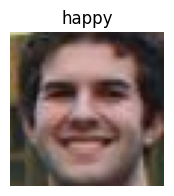

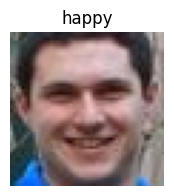

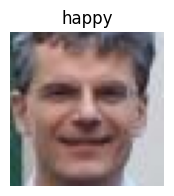

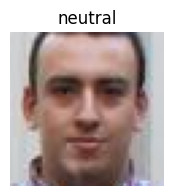

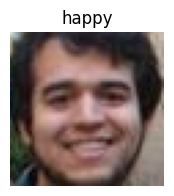

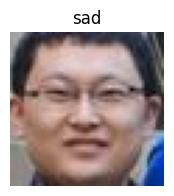

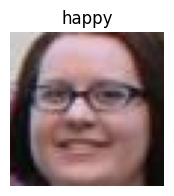

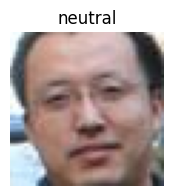

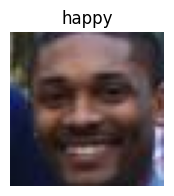

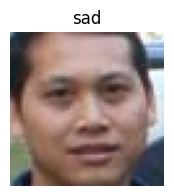

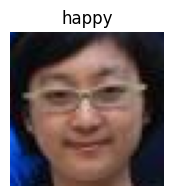

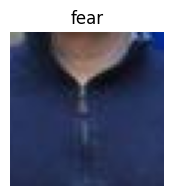

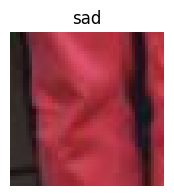

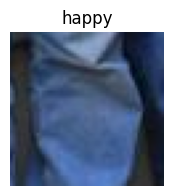

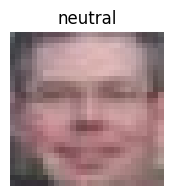

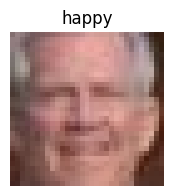

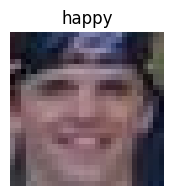

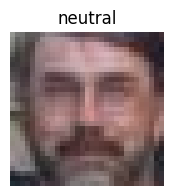

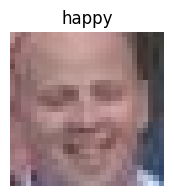

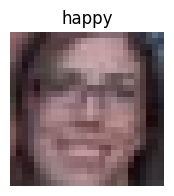

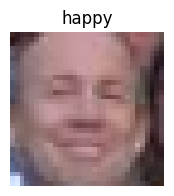

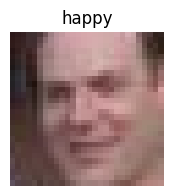

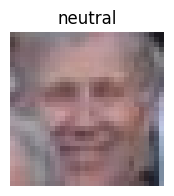

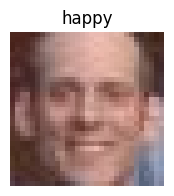

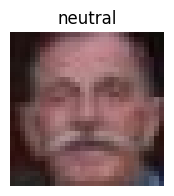

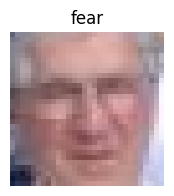

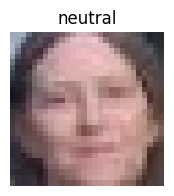

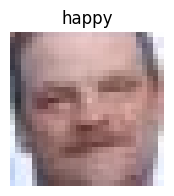

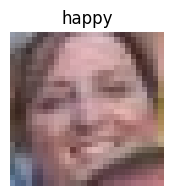

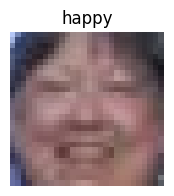

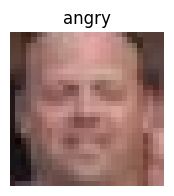

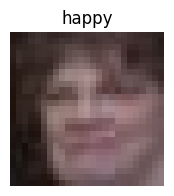

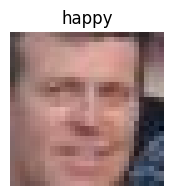

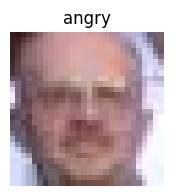

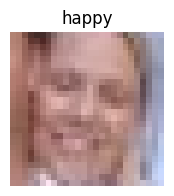

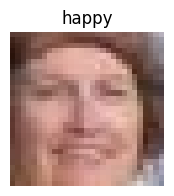

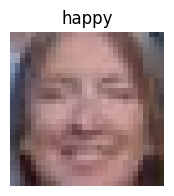

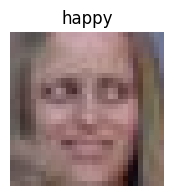

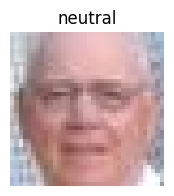

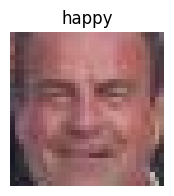

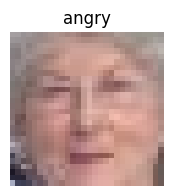

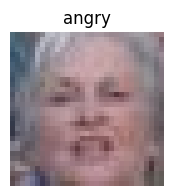

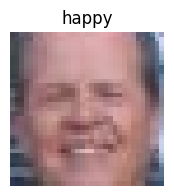

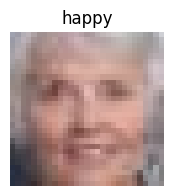

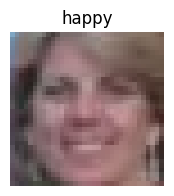

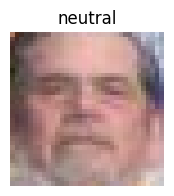

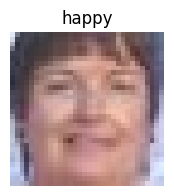

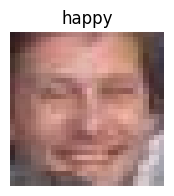

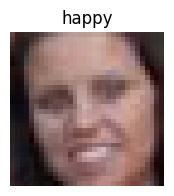

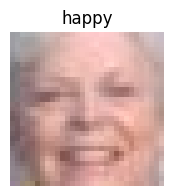

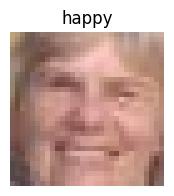

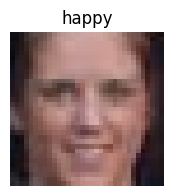

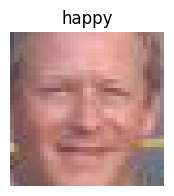

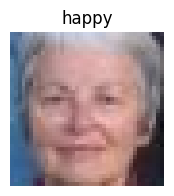

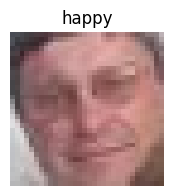

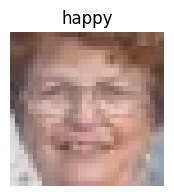

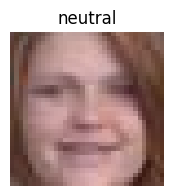

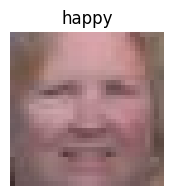

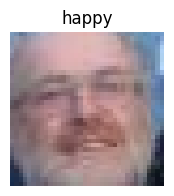

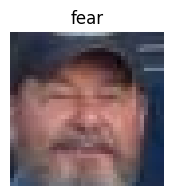

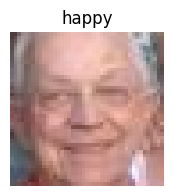

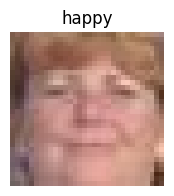

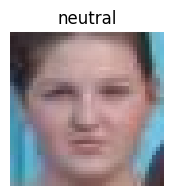

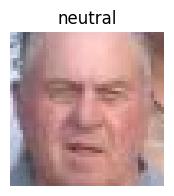

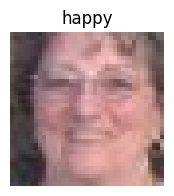

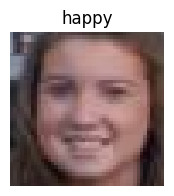

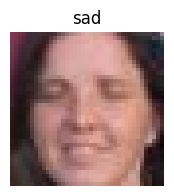

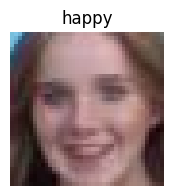

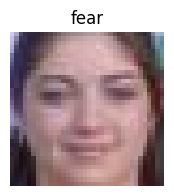

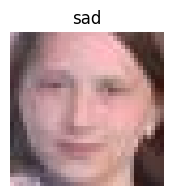

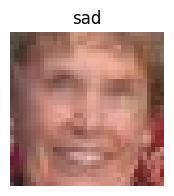

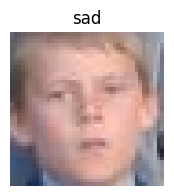

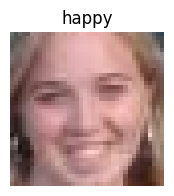

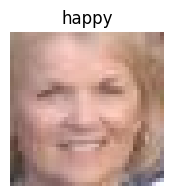

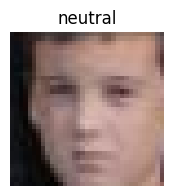

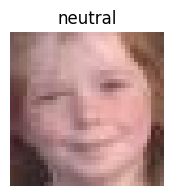

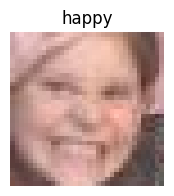

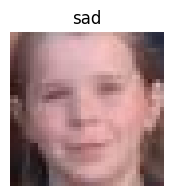

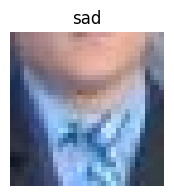

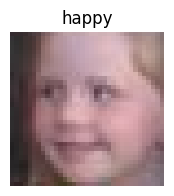

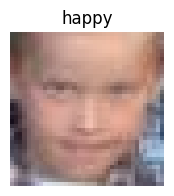

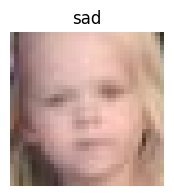

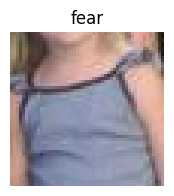

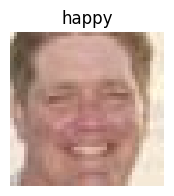

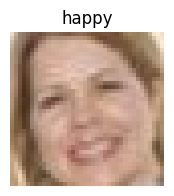

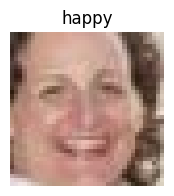

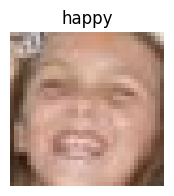

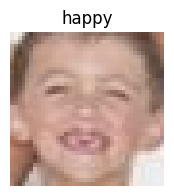

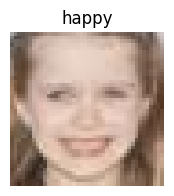

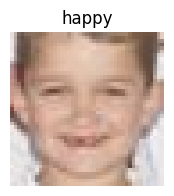

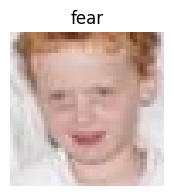

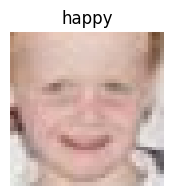

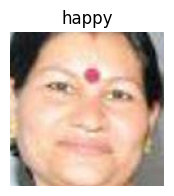

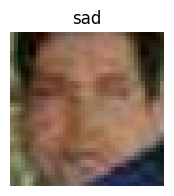

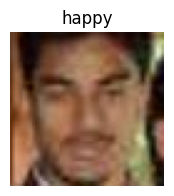

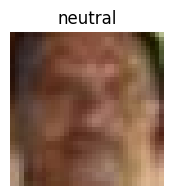

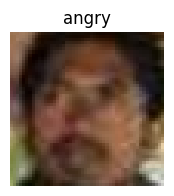

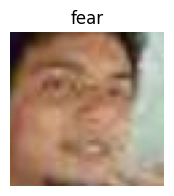

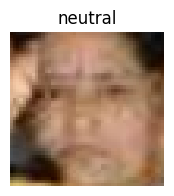

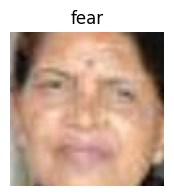

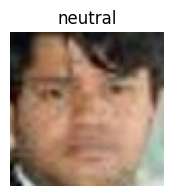

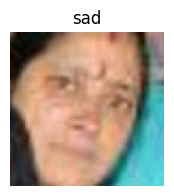

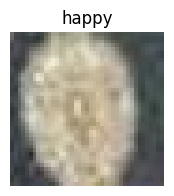

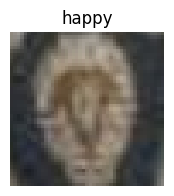

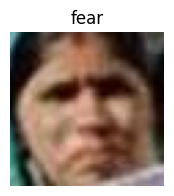

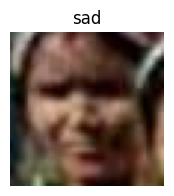

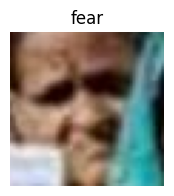

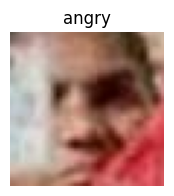

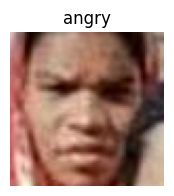

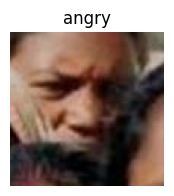

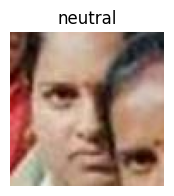

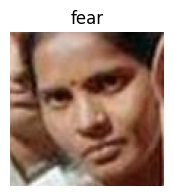

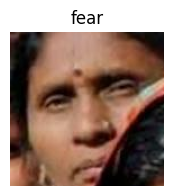

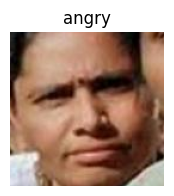

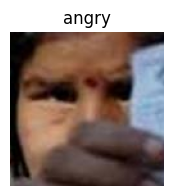

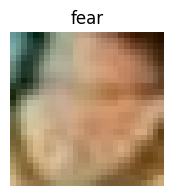

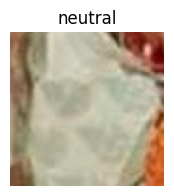

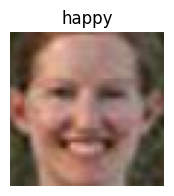

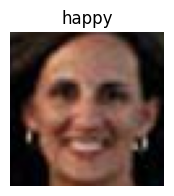

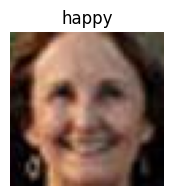

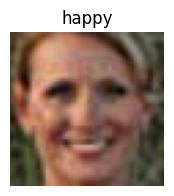

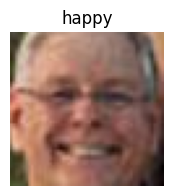

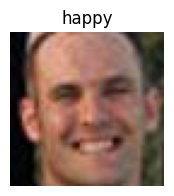

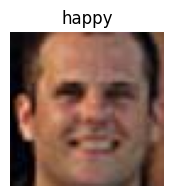

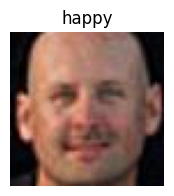

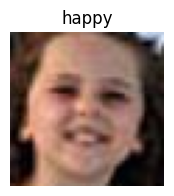

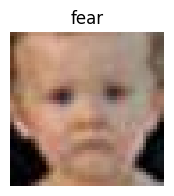

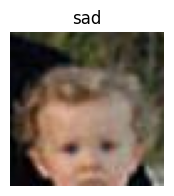

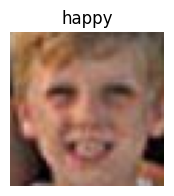

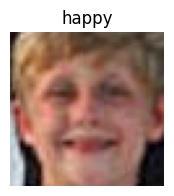

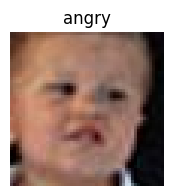

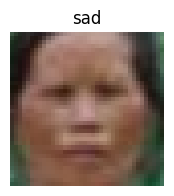

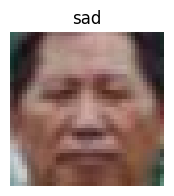

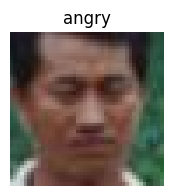

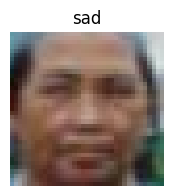

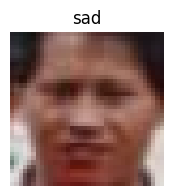

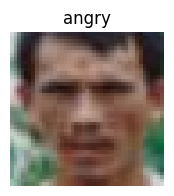

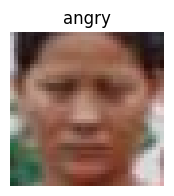

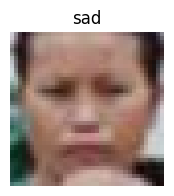

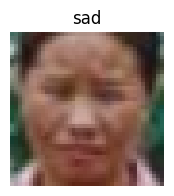

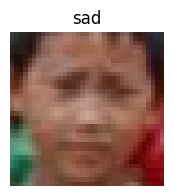

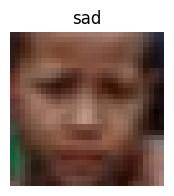

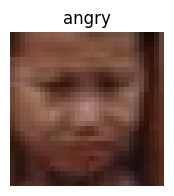

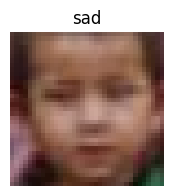

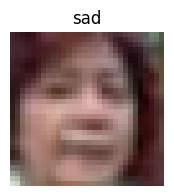

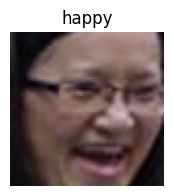

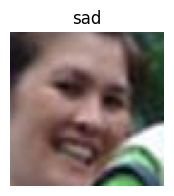

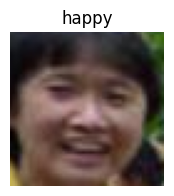

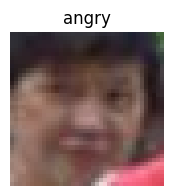

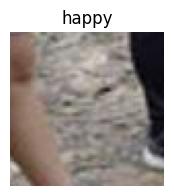

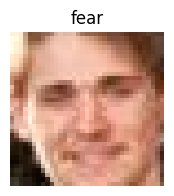

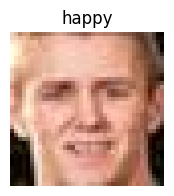

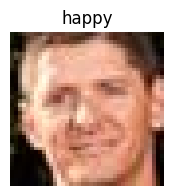

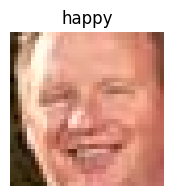

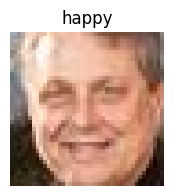

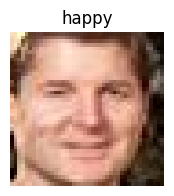

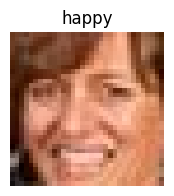

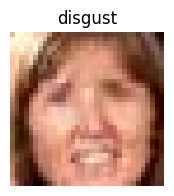

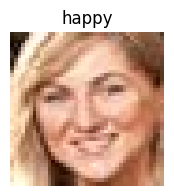

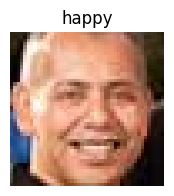

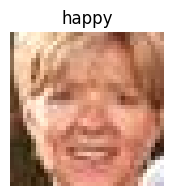

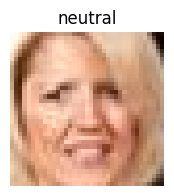

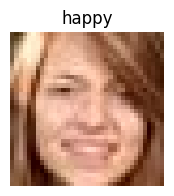

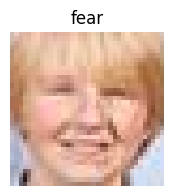

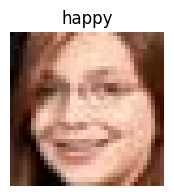

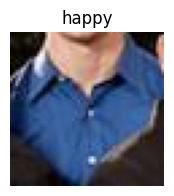

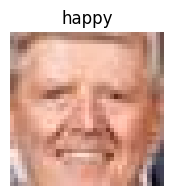

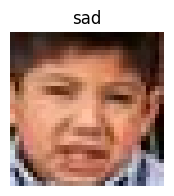

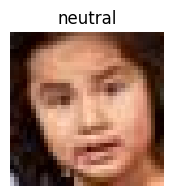

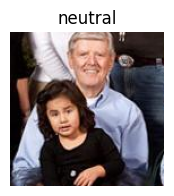

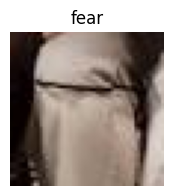

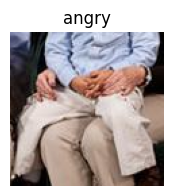

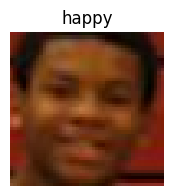

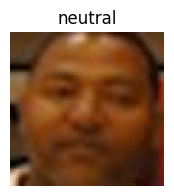

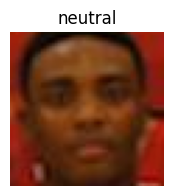

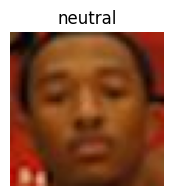

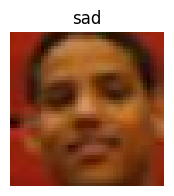

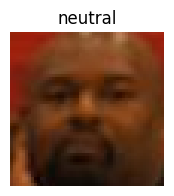

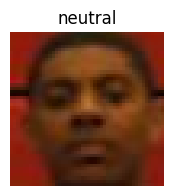

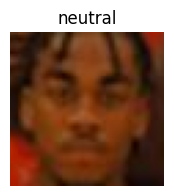

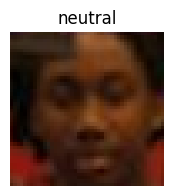

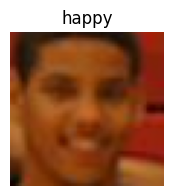

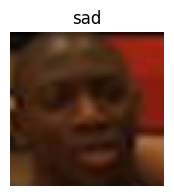

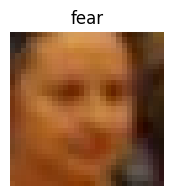

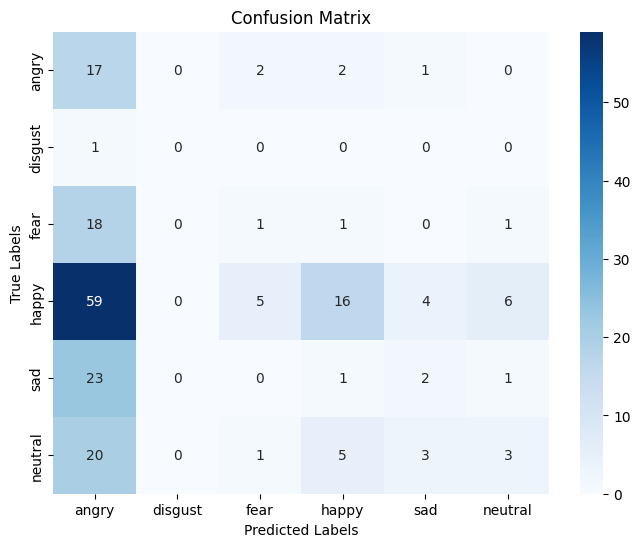

In [155]:
# Validate when number of persons is more than 10 in the image
# First parameter is the test file location
# Second parameter is the label file location
validate(Config.IMAGE_DIRECTORY + 'Above10', Config.LABEL_FILE)

#Final observation:
#The model's performance, as indicated by the Cross-Entropy Total Loss of 20.2718 and the Cross-Entropy Group-level Average Loss of 10.4819,
#significant discrepancies between predicted and actual emotions within the group images. These values imply a substantial divergence from the expected emotions

No Clear Faces in group of image

Image name: 56_Voter_peoplevoting_56_541


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 20.33it/s]


Image name: 56_Voter_peoplevoting_56_89


Action: emotion: 100%|██████████| 1/1 [00:00<00:00,  5.08it/s]


Image name: 56_Voter_peoplevoting_56_461


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 22.62it/s]


Image name: 56_Voter_peoplevoting_56_33
Image name: 56_Voter_peoplevoting_56_158
Image name: 56_Voter_peoplevoting_56_713
Cross-Entropy Total Loss: 1.9078
Cross-Entropy Group-level Average Loss: 1.9268
Image 1 Loss: 1.9459
Image 2 Loss: 1.9459
Image 3 Loss: 1.8314
Image 4 Loss: 1.9459
Image 5 Loss: 1.9459
Image 6 Loss: 1.9459


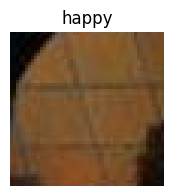

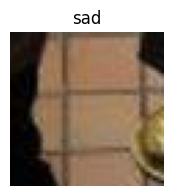

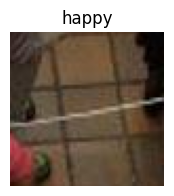

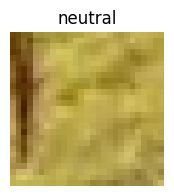

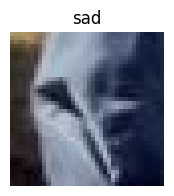

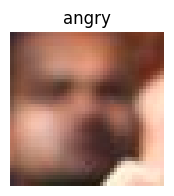

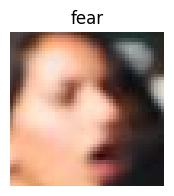

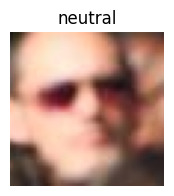

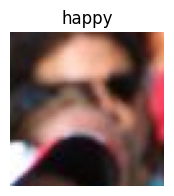

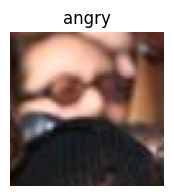

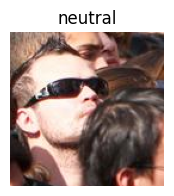

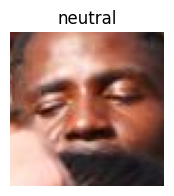

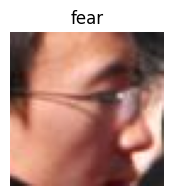

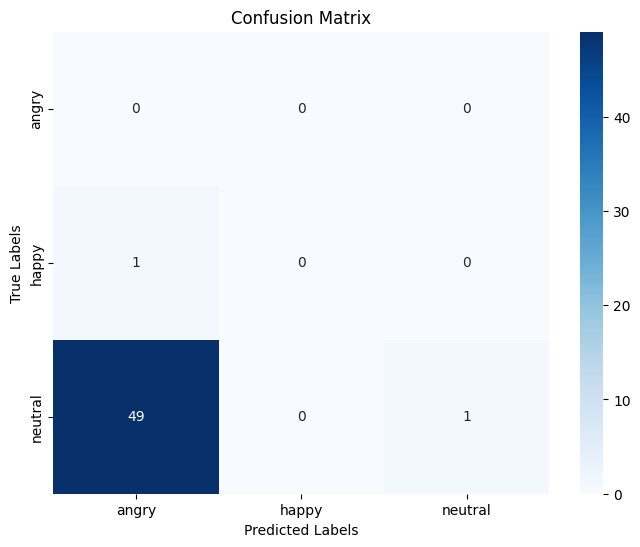

In [156]:
#Group Images with Unclear Faces
#First parameter is Test file location
#Scond parameter is Label file location
validate(Config.IMAGE_DIRECTORY + 'UnclearFaces', Config.LABEL_FILE)

#Final observation:
#The model's performance, as indicated by the Cross-Entropy Total Loss of 1.9078 and the Cross-Entropy Group-level Average Loss of 1.9268,
#significant discrepancies between predicted and actual emotions within the group images. These values imply a substantial divergence from the expected emotions

Low Light Images

Image name: 20_Family_Group_Family_Group_20_257


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 19.37it/s]


Image name: 35_Basketball_basketballgame_ball_35_265


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 17.01it/s]


Image name: 12_Group_Group_12_Group_Group_12_705


...

Image name: 35_Basketball_playingbasketball_35_635


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 20.65it/s]


Image name: 17_Ceremony_Ceremony_17_401


Action: emotion: 100%|██████████| 1/1 [00:00<00:00, 20.10it/s]


Image name: 50_Celebration_Or_Party_houseparty_50_72
Cross-Entropy Total Loss: 30.7226
Cross-Entropy Group-level Average Loss: 22.4074
Image 1 Loss: 29.3763
Image 2 Loss: 25.6525
Image 3 Loss: 22.1494
Image 4 Loss: 1.9459
Image 5 Loss: 1.4594
Image 6 Loss: 56.3944
Image 7 Loss: 38.5165
Image 8 Loss: 1.9459
Image 9 Loss: 44.6877
Image 10 Loss: 1.9459


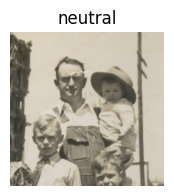

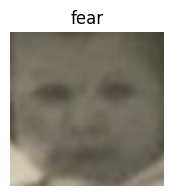

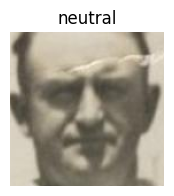

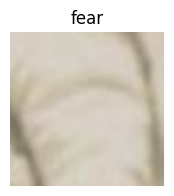

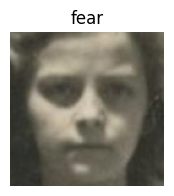

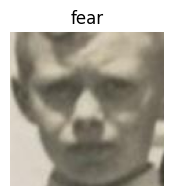

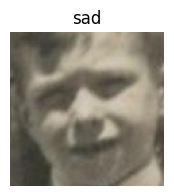

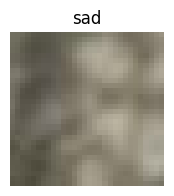

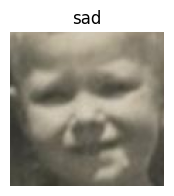

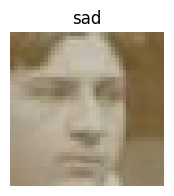

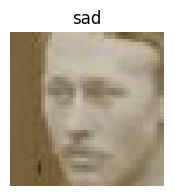

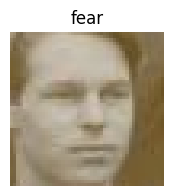

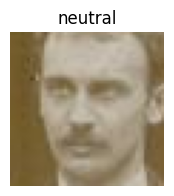

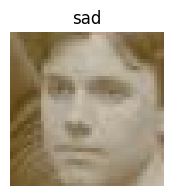

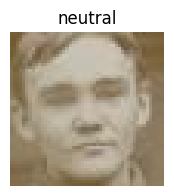

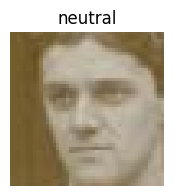

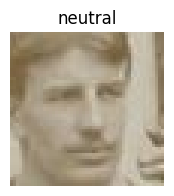

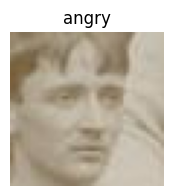

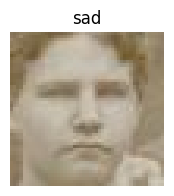

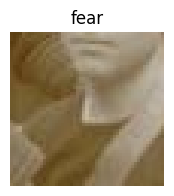

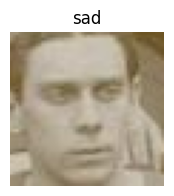

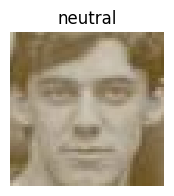

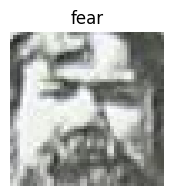

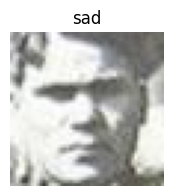

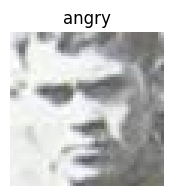

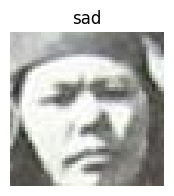

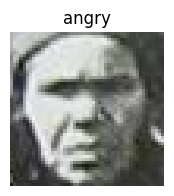

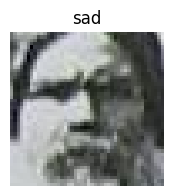

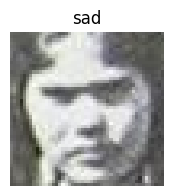

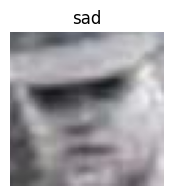

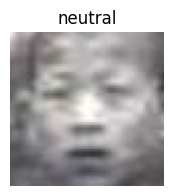

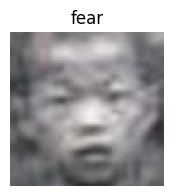

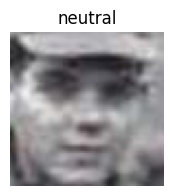

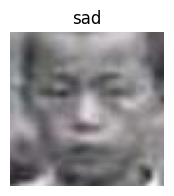

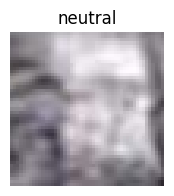

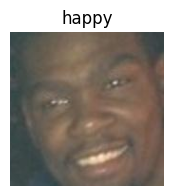

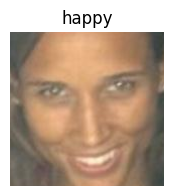

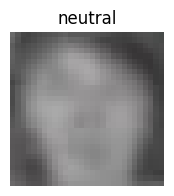

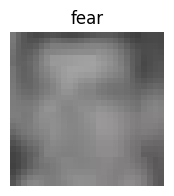

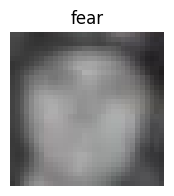

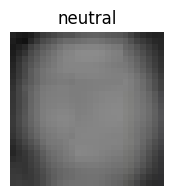

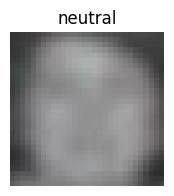

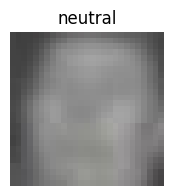

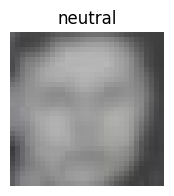

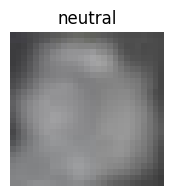

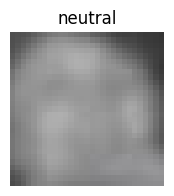

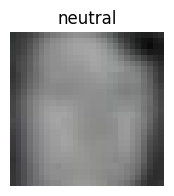

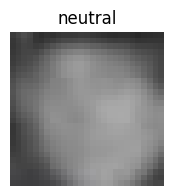

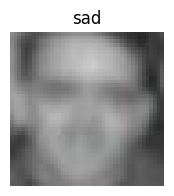

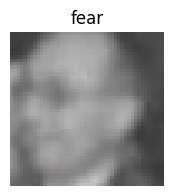

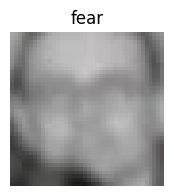

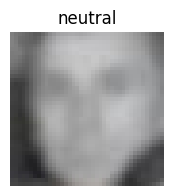

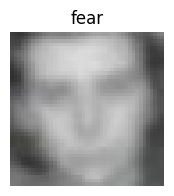

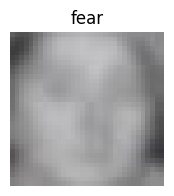

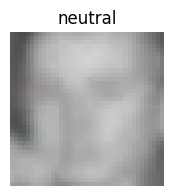

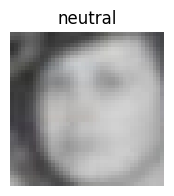

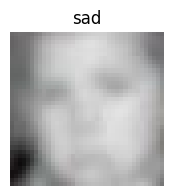

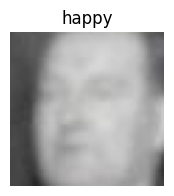

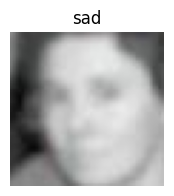

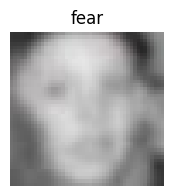

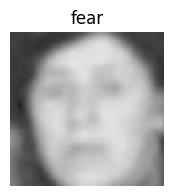

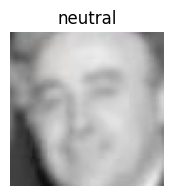

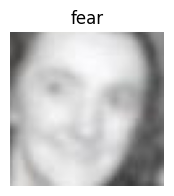

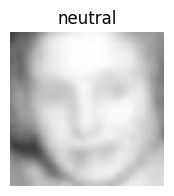

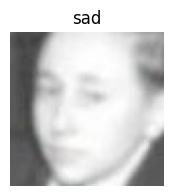

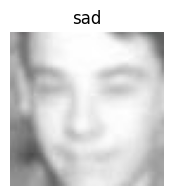

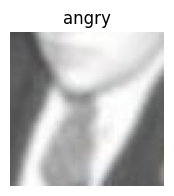

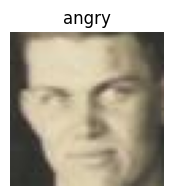

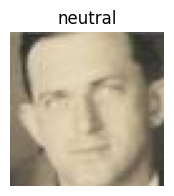

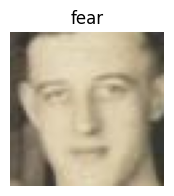

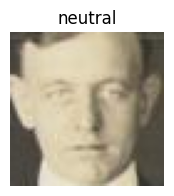

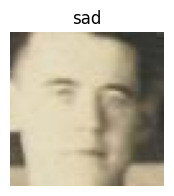

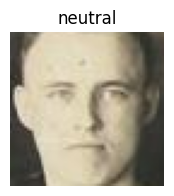

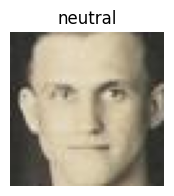

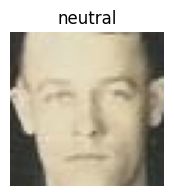

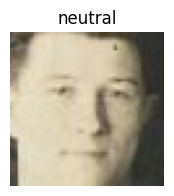

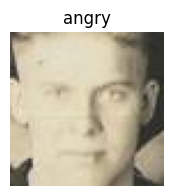

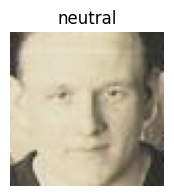

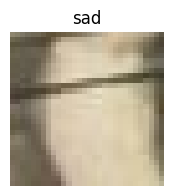

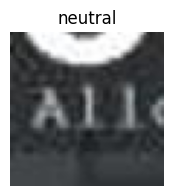

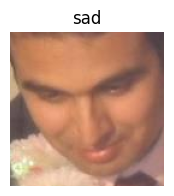

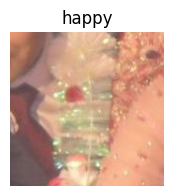

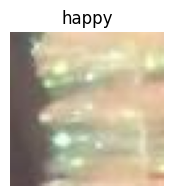

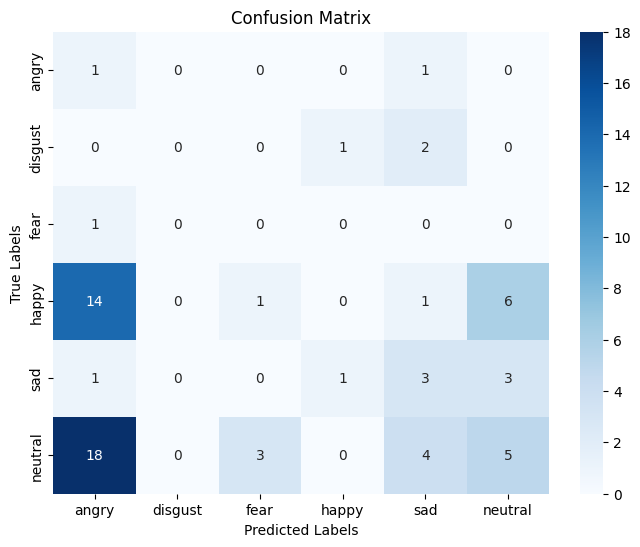

In [157]:
#Low Light images
#First parameter is Test file location
#Scond parameter is Label file location
validate(Config.IMAGE_DIRECTORY + 'LowLight', Config.LABEL_FILE)

#Final observation:
#The model's performance, as indicated by the Cross-Entropy Total Loss of 29.1432 and the Cross-Entropy Group-level Average Loss of 22.0139,
#significant discrepancies between predicted and actual emotions within the group images. These values imply a substantial divergence from the expected emotions

#Summary:

The code encompasses an emotion recognition system using OpenCV and DeepFace libraries. It facilitates group-level emotion recognition by analyzing images, extracting individual faces, and predicting emotions using pre-trained models. However, it faces challenges with images containing more than 10 individuals or unclear faces, impacting accuracy. The model's performance shows considerable discrepancies between predicted and actual emotions, warranting further refinement for enhanced accuracy.

Future Changes:

Improve DeepFace's handling of images with more than 10 individuals for better scalability.
Enhance face detection for images with obscured or unclear faces to bolster recognition accuracy.
Explore alternative emotion recognition models or augment the existing model to better differentiate emotions within group settings.
Implement measures for handling low-light scenarios to improve recognition in challenging conditions.
Extend evaluation metrics to include additional criteria beyond cross-entropy loss, like precision and recall.